# Split-Half Pattern Correlation — Native Space

Within-subject split-half pattern correlation across the 4 visual categories,
computed in each subject's native anat space (no MNI registration needed).

**Logic (Haxby 2001 / Spiridon & Kanwisher 2002 style):**
- Split runs into halves (even/odd or any 2-way split)
- Per half, per category: average run-level beta patterns
- Correlate half1_X with half2_Y for all (X, Y) pairs
- Within-category (X=Y) correlation tests whether the same category produces
  the same pattern across independent halves
- Between-category (X≠Y) correlation tests whether different categories share
  patterns

**Distinctiveness = mean(within) - mean(between).** Higher = categories more
distinct in this VOTC.

**Group test:** patient distinctiveness vs control distinctiveness, per category × hemi.

**Pipeline alignment:**
- Native anat space (FEAT 1stLevel registered to ses-01 anat via register_zstats.py)
- Raw beta copes 15-18 (face, house, object, word) from `reg_standard/stats/`
- Whole-VOTC mask = union of 4 category searchmasks per subject (LH and RH separately)
- WTA threshold not used (this is multivariate, all voxels included)


## Setup

In [1]:
import os, sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv, get_runs)

CATEGORIES = ['face', 'house', 'object', 'word']
RAW_BETA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}

EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

N_PERM = 10000
RNG_SEED = 42

OUT_DIR = os.path.join(processed_dir, 'group_results', 'voxel_split_half_native')
os.makedirs(OUT_DIR, exist_ok=True)
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Output: {OUT_DIR}')

Output: /user_data/csimmon2/sym_pt/group_results/voxel_split_half_native


## Helpers

In [2]:
def load_subjects():
    """Cross-sectional, OTC + control, no nonOTC, first post-surgery session."""
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs: continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        group = info.get('group', 'unknown')
        code_str = f"{group}{sc}"
        if code_str in EXTRA_SKIP or sid in EXTRA_SKIP: continue
        if group == 'nonOTC': continue

        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if ses_str in PRE_SURGERY_SESSIONS.get(sid, set()):
                continue
            post_sessions.append(ses_str)
        if not post_sessions: continue

        subjects[sid] = {
            'session': post_sessions[0],
            'group': group,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


def get_runs_for(sub_clean, ses):
    """Get run numbers from raw dir."""
    return get_runs(f'sub-{sub_clean}', int(ses))


def get_run_beta_path(sub_id, ses, run, cope_num):
    """Run-level beta cope in ses-01 anat space (output of register_zstats.py)."""
    return os.path.join(processed_dir, sub_id, f'ses-{ses}',
                        'derivatives', 'fsl', 'loc', f'run-{run:02d}',
                        '1stLevel.feat', 'reg_standard', 'stats',
                        f'cope{cope_num}.nii.gz')


def get_native_votc_mask(sub_id, ses):
    """Union of 4 category searchmasks per hemi → whole-VOTC native mask."""
    roi_dir = os.path.join(processed_dir, sub_id, f'ses-{ses}', 'ROIs')
    masks = {'l': None, 'r': None}
    affine = None
    for h in ['l', 'r']:
        for cat in ['face', 'house', 'object', 'word']:
            path = os.path.join(roi_dir, f'{h}_{cat}_searchmask.nii.gz')
            if not os.path.exists(path):
                continue
            img = nib.load(path)
            d = img.get_fdata() > 0
            if masks[h] is None:
                masks[h] = d.copy()
                affine = img.affine
            else:
                masks[h] = masks[h] | d
    return masks, affine


def load_split_betas(sub_id, ses, runs, mask):
    """Average run-level betas per category per half. Returns dict[half][cat] = 1D array."""
    if len(runs) < 2:
        return None
    half1 = runs[::2]   # odd-indexed (0, 2, 4...)
    half2 = runs[1::2]  # even-indexed
    if not half1 or not half2:
        return None

    halves = {1: half1, 2: half2}
    out = {1: {}, 2: {}}
    for h_idx, h_runs in halves.items():
        for cat, cope in RAW_BETA_COPES.items():
            arrs = []
            for r in h_runs:
                p = get_run_beta_path(sub_id, ses, r, cope)
                if not os.path.exists(p):
                    return None
                arrs.append(nib.load(p).get_fdata()[mask])
            out[h_idx][cat] = np.mean(arrs, axis=0)
    return out, half1, half2


def perm_test(g1, g2, n_perm=N_PERM, seed=RNG_SEED):
    g1 = np.asarray(g1, float); g1 = g1[np.isfinite(g1)]
    g2 = np.asarray(g2, float); g2 = g2[np.isfinite(g2)]
    if len(g1) < 2 or len(g2) < 2:
        return np.nan, np.nan
    obs = g1.mean() - g2.mean()
    pool = np.concatenate([g1, g2])
    n1 = len(g1)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n1].mean() - perm[n1:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()


print('Helpers defined.')

Helpers defined.


## Compute split-half correlations per subject × hemi

In [3]:
subjects = load_subjects()
print(f'Loaded {len(subjects)} subjects')

results = []
skipped = []

for sid, info in subjects.items():
    ses = info['session']
    sub_clean = sid.replace('sub-', '')
    runs = get_runs_for(sub_clean, ses)
    if len(runs) < 2:
        skipped.append((sid, 'fewer than 2 runs'))
        continue

    masks, affine = get_native_votc_mask(sid, ses)
    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]

    for h in hemis:
        if masks.get(h) is None or int(masks[h].sum()) == 0:
            skipped.append((sid, h, 'no VOTC mask'))
            continue

        out = load_split_betas(sid, ses, runs, masks[h])
        if out is None:
            skipped.append((sid, h, 'missing run betas'))
            continue
        halves, h1_runs, h2_runs = out

        # Cocktail-blank demean per half (per voxel across categories)
        for h_idx in [1, 2]:
            mat = np.column_stack([halves[h_idx][c] for c in CATEGORIES])
            mat = mat - mat.mean(axis=1, keepdims=True)
            for i, c in enumerate(CATEGORIES):
                halves[h_idx][c] = mat[:, i]

        # 4x4 cross-half correlation matrix
        corr_mat = np.zeros((4, 4))
        for i, c1 in enumerate(CATEGORIES):
            for j, c2 in enumerate(CATEGORIES):
                corr_mat[i, j] = np.corrcoef(halves[1][c1], halves[2][c2])[0, 1]

        within = np.diag(corr_mat).mean()
        # between = mean of off-diagonals (both directions averaged)
        off = corr_mat.copy()
        np.fill_diagonal(off, np.nan)
        between = np.nanmean(off)
        distinctiveness = within - between

        # Per-category distinctiveness: corr(c, c) - mean(corr(c, others))
        per_cat = {}
        for i, cat in enumerate(CATEGORIES):
            within_c = corr_mat[i, i]
            between_c = np.nanmean([corr_mat[i, j] for j in range(4) if j != i])
            per_cat[cat] = within_c - between_c

        results.append({
            'sub': sid, 'hemi': h, 'group': info['group'],
            'surgery_side': info.get('surgery_side', 'na'),
            'n_voxels': int(masks[h].sum()),
            'n_runs': len(runs),
            'within': within, 'between': between, 'distinctiveness': distinctiveness,
            'face_d': per_cat['face'], 'house_d': per_cat['house'],
            'object_d': per_cat['object'], 'word_d': per_cat['word'],
            'corr_mat': corr_mat,
        })

print(f'\nComputed: {len(results)} sub-hemi entries')
if skipped:
    print(f'Skipped {len(skipped)}:')
    for s in skipped[:15]:
        print(f'  {s}')
    if len(skipped) > 15:
        print(f'  ... and {len(skipped)-15} more')

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'corr_mat'}
                            for r in results])
print(f'\n{results_df.groupby(["group", "hemi"])["distinctiveness"].describe().round(3)}')

Loaded 63 subjects

Computed: 54 sub-hemi entries
Skipped 47:
  ('sub-001', 'l', 'no VOTC mask')
  ('sub-001', 'r', 'no VOTC mask')
  ('sub-005', 'l', 'no VOTC mask')
  ('sub-016', 'l', 'no VOTC mask')
  ('sub-016', 'r', 'no VOTC mask')
  ('sub-021', 'r', 'no VOTC mask')
  ('sub-023', 'l', 'no VOTC mask')
  ('sub-023', 'r', 'no VOTC mask')
  ('sub-026', 'l', 'no VOTC mask')
  ('sub-026', 'r', 'no VOTC mask')
  ('sub-027', 'l', 'no VOTC mask')
  ('sub-027', 'r', 'no VOTC mask')
  ('sub-028', 'l', 'no VOTC mask')
  ('sub-028', 'r', 'no VOTC mask')
  ('sub-029', 'l', 'no VOTC mask')
  ... and 32 more

              count   mean    std    min    25%    50%    75%    max
group   hemi                                                        
OTC     l       9.0  0.572  0.339  0.024  0.405  0.702  0.845  0.942
        r       7.0  0.702  0.288  0.224  0.575  0.706  0.887  1.062
control l      19.0  0.797  0.149  0.528  0.710  0.819  0.900  1.057
        r      19.0  0.834  0.141  0.573  0.754  

## Group-level perm tests

In [4]:
print('=' * 78)
print('SPLIT-HALF DISTINCTIVENESS — perm test (OTC vs control)')
print('Distinctiveness = within-category r minus between-category r')
print('=' * 78)
print(f'\n{"Hemi":>6} {"Cat":>10} {"Ctrl M":>8} {"OTC M":>8} {"Δ":>8} {"p":>8} {"Sig":>4}')
print('-' * 60)

perm_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    # Overall distinctiveness
    ctrl_v = results_df[(results_df['group']=='control') &
                         (results_df['hemi']==h)]['distinctiveness'].values
    otc_v  = results_df[(results_df['group']=='OTC') &
                         (results_df['hemi']==h)]['distinctiveness'].values
    if len(otc_v) >= 2 and len(ctrl_v) >= 2:
        delta, p = perm_test(otc_v, ctrl_v)
        sig = '*' if p < .05 else ('†' if p < .10 else '')
        perm_results.append({'hemi': label, 'category': 'overall',
                             'ctrl_m': ctrl_v.mean(), 'otc_m': otc_v.mean(),
                             'delta': delta, 'p_perm': p,
                             'n_ctrl': len(ctrl_v), 'n_otc': len(otc_v)})
        print(f'{label:>6} {"overall":>10} {ctrl_v.mean():>8.3f} {otc_v.mean():>8.3f} '
              f'{delta:>8.3f} {p:>8.4f} {sig:>4}')

    # Per-category
    for cat in CATEGORIES:
        col = f'{cat}_d'
        ctrl_v = results_df[(results_df['group']=='control') &
                             (results_df['hemi']==h)][col].values
        otc_v  = results_df[(results_df['group']=='OTC') &
                             (results_df['hemi']==h)][col].values
        if len(otc_v) < 2 or len(ctrl_v) < 2: continue
        delta, p = perm_test(otc_v, ctrl_v)
        sig = '*' if p < .05 else ('†' if p < .10 else '')
        perm_results.append({'hemi': label, 'category': cat,
                             'ctrl_m': ctrl_v.mean(), 'otc_m': otc_v.mean(),
                             'delta': delta, 'p_perm': p,
                             'n_ctrl': len(ctrl_v), 'n_otc': len(otc_v)})
        print(f'{label:>6} {cat:>10} {ctrl_v.mean():>8.3f} {otc_v.mean():>8.3f} '
              f'{delta:>8.3f} {p:>8.4f} {sig:>4}')

perm_df = pd.DataFrame(perm_results)
perm_df.to_csv(os.path.join(OUT_DIR, 'split_half_distinctiveness_xs_perm.csv'),
               index=False)

SPLIT-HALF DISTINCTIVENESS — perm test (OTC vs control)
Distinctiveness = within-category r minus between-category r

  Hemi        Cat   Ctrl M    OTC M        Δ        p  Sig
------------------------------------------------------------
    LH    overall    0.797    0.572   -0.225   0.0159    *
    LH       face    0.728    0.531   -0.197   0.1226     
    LH      house    0.840    0.582   -0.258   0.0594    †
    LH     object    0.800    0.578   -0.222   0.0279    *
    LH       word    0.820    0.596   -0.224   0.0492    *
    RH    overall    0.834    0.702   -0.132   0.1299     
    RH       face    0.710    0.729    0.020   0.8704     
    RH      house    0.881    0.693   -0.187   0.1489     
    RH     object    0.737    0.675   -0.062   0.5389     
    RH       word    1.009    0.711   -0.298   0.0012    *


## Visualize: average split-half correlation matrices per group × hemi

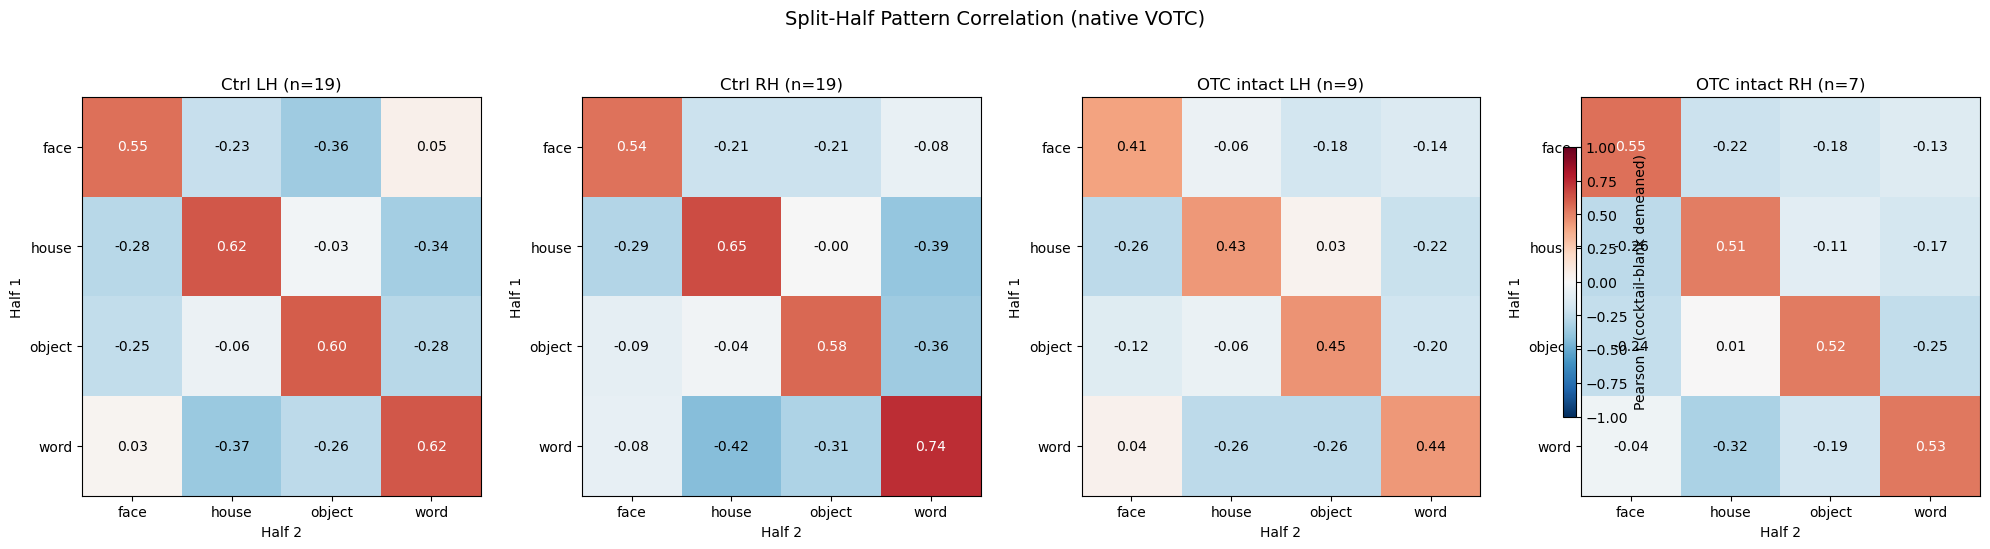

In [5]:
def avg_corr_mat(group, hemi):
    mats = [r['corr_mat'] for r in results
            if r['group'] == group and r['hemi'] == hemi]
    if not mats:
        return None, 0
    return np.mean(mats, axis=0), len(mats)


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
panels = [
    ('Ctrl LH',       'control', 'l'),
    ('Ctrl RH',       'control', 'r'),
    ('OTC intact LH', 'OTC',     'l'),
    ('OTC intact RH', 'OTC',     'r'),
]
for ax, (title, group, hemi) in zip(axes, panels):
    mat, n = avg_corr_mat(group, hemi)
    if mat is None:
        ax.set_title(f'{title} (no data)'); ax.axis('off'); continue
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES); ax.set_yticklabels(CATEGORIES)
    ax.set_xlabel('Half 2'); ax.set_ylabel('Half 1')
    ax.set_title(f'{title} (n={n})')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    color='white' if abs(mat[i, j]) > 0.5 else 'black',
                    fontsize=10)

plt.colorbar(im, ax=axes, shrink=0.7, label='Pearson r (cocktail-blank demeaned)')
plt.suptitle('Split-Half Pattern Correlation (native VOTC)',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'split_half_corr_matrix_xs.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Per-category distinctiveness boxplot

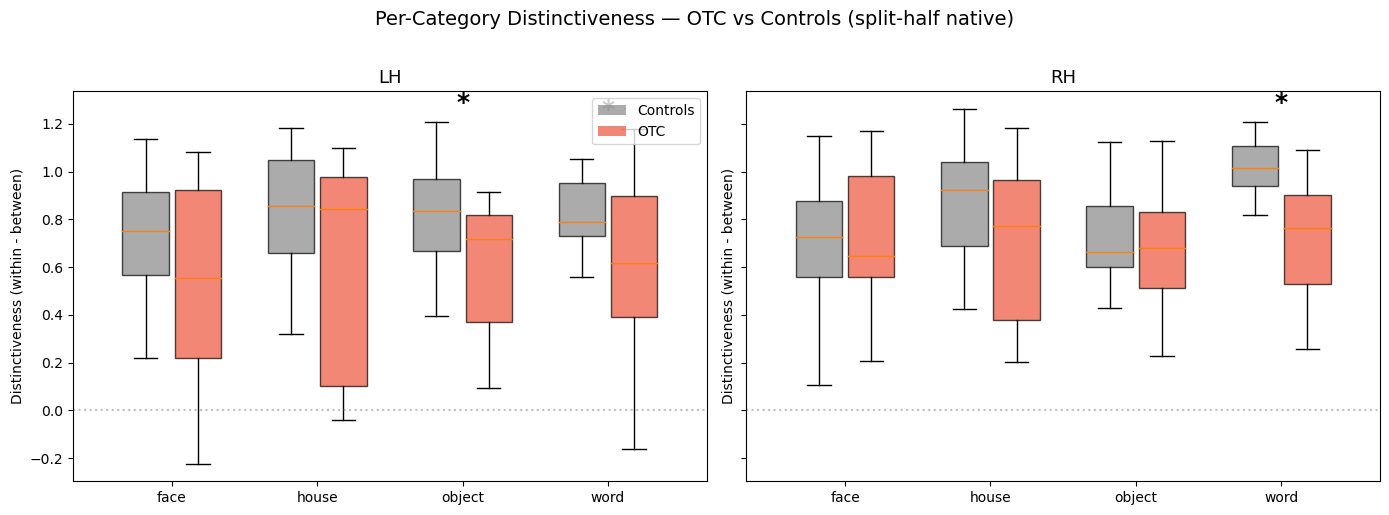

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, h, label in zip(axes, ['l', 'r'], ['LH', 'RH']):
    data = []
    positions = []
    colors = []
    for i, cat in enumerate(CATEGORIES):
        col = f'{cat}_d'
        c = results_df[(results_df['group']=='control') &
                       (results_df['hemi']==h)][col].values
        o = results_df[(results_df['group']=='OTC') &
                       (results_df['hemi']==h)][col].values
        positions.extend([i - 0.18, i + 0.18])
        data.extend([c, o])
        colors.extend(['#888888', '#EF553B'])

    bp = ax.boxplot(data, positions=positions, widths=0.32,
                    patch_artist=True, showfliers=False)
    for p, c in zip(bp['boxes'], colors):
        p.set_facecolor(c); p.set_alpha(0.7)

    for i, cat in enumerate(CATEGORIES):
        row = perm_df[(perm_df['hemi']==label) & (perm_df['category']==cat)]
        if len(row) and row.iloc[0]['p_perm'] < .05:
            ymax = max([d.max() for d in data[2*i:2*i+2] if len(d)])
            ax.text(i, ymax + 0.05, '*', fontsize=18, ha='center', fontweight='bold')

    ax.set_xticks(range(4)); ax.set_xticklabels(CATEGORIES)
    ax.set_ylabel('Distinctiveness (within - between)')
    ax.set_title(label, fontsize=13)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

from matplotlib.patches import Patch
legend = [Patch(facecolor='#888888', alpha=0.7, label='Controls'),
          Patch(facecolor='#EF553B', alpha=0.7, label='OTC')]
axes[0].legend(handles=legend, loc='upper right')

plt.suptitle('Per-Category Distinctiveness — OTC vs Controls (split-half native)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distinctiveness_per_cat_xs.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Save summary

In [7]:
results_df.to_csv(os.path.join(OUT_DIR, 'split_half_summary_xs.csv'), index=False)
print(f'Saved: {OUT_DIR}')

Saved: /user_data/csimmon2/sym_pt/group_results/voxel_split_half_native


## Notes

**Why native space is fine here:** Split-half is a within-subject test. Each subject's
two halves are in the same space. We never compare voxel-to-voxel across subjects;
we only compare per-subject scalar distinctiveness scores at the group level.

**Cocktail-blank demeaning** applied per half before correlation, following Garrido
et al. 2013 / Haxby et al. 2001. This removes the shared visual-activation
component so correlations reflect category-tuning structure, not baseline activity.

**Interpretation:**
- Within-category r > 0 means the same category produces a reliable pattern across runs
- Between-category r near 0 (or negative after demeaning) means categories produce distinct patterns
- Distinctiveness = within - between; reduced distinctiveness = patient categories less differentiated